In [7]:
# Think of this like opening your toolbox before starting work
import os                          # to navigate folders
import numpy as np                 # for math operations
import matplotlib.pyplot as plt    # for drawing graphs and showing images
from PIL import Image              # for opening image files
import torch                       # our AI brain library

# ✅ Let's confirm GPU is available
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("✅ Toolbox ready!")

GPU Available: True
GPU Name: Quadro T1000
✅ Toolbox ready!


In [8]:
# Tell Python WHERE your images are stored
# Think of this like giving someone the address of your house

base_dir = r"C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\chest_xray"

train_dir  = os.path.join(base_dir, "train")
val_dir    = os.path.join(base_dir, "val")
test_dir   = os.path.join(base_dir, "test")

# Let's count how many images we have in each folder
for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(base_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split:6} | {label:10} | {count} images")

train  | NORMAL     | 1341 images
train  | PNEUMONIA  | 3875 images
val    | NORMAL     | 8 images
val    | PNEUMONIA  | 8 images
test   | NORMAL     | 234 images
test   | PNEUMONIA  | 390 images


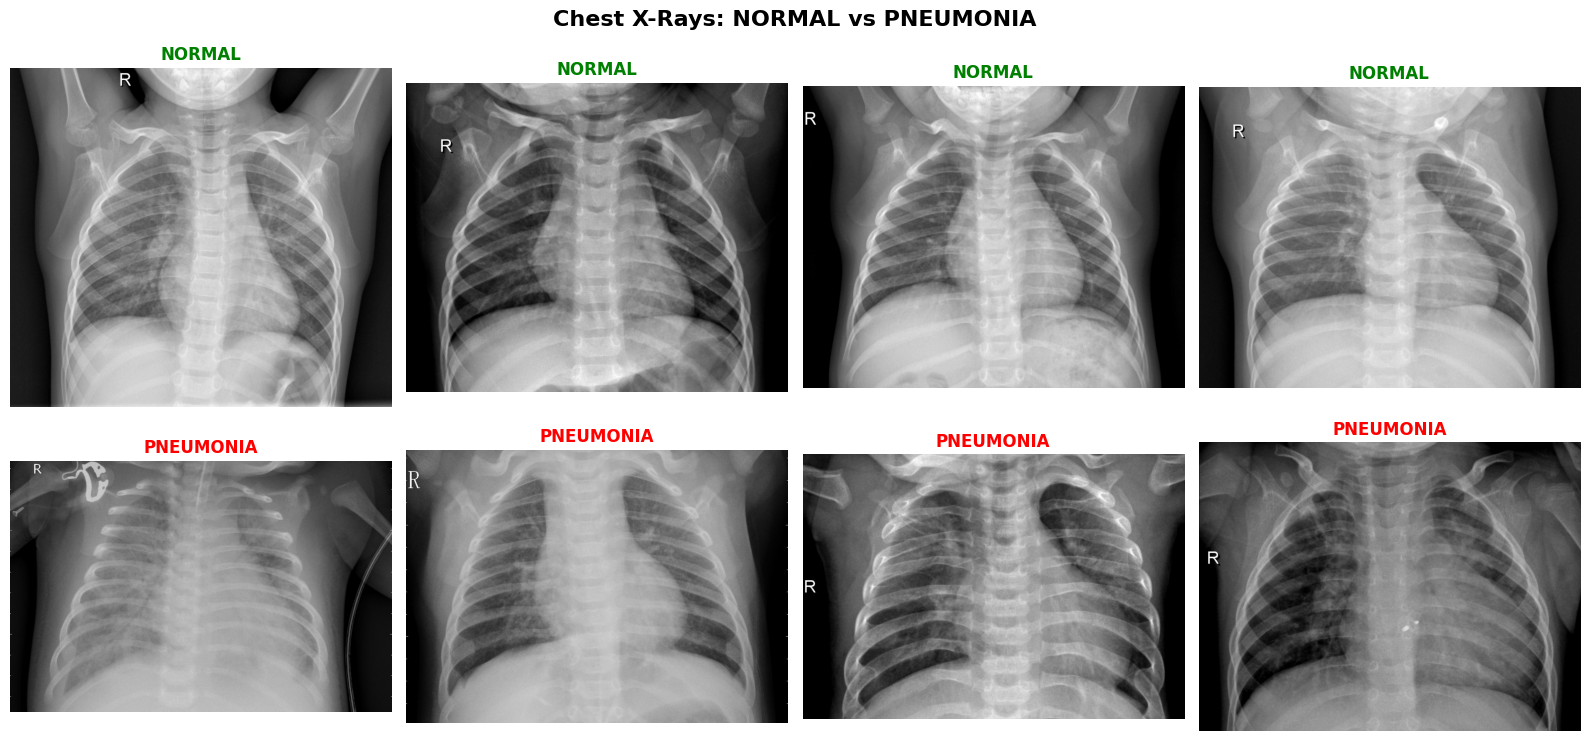

✅ Images displayed!


In [9]:
# Let's actually LOOK at some X-ray images
# We'll show 4 NORMAL and 4 PNEUMONIA side by side

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Chest X-Rays: NORMAL vs PNEUMONIA", fontsize=16, fontweight='bold')

for i, label in enumerate(["NORMAL", "PNEUMONIA"]):
    folder = os.path.join(train_dir, label)
    images = os.listdir(folder)[:4]   # grab first 4 images

    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).convert("L")   # "L" = grayscale (black & white)
        
        axes[i][j].imshow(img, cmap="gray")
        axes[i][j].set_title(label, color="green" if label=="NORMAL" else "red",
                             fontweight='bold')
        axes[i][j].axis("off")   # hide the x/y axis numbers

plt.tight_layout()
plt.savefig("sample_xrays.png", dpi=150)   # save the image
plt.show()
print("✅ Images displayed!")

Normal images    : 1341  (25.7%)
Pneumonia images : 3875  (74.3%)
Total            : 5216


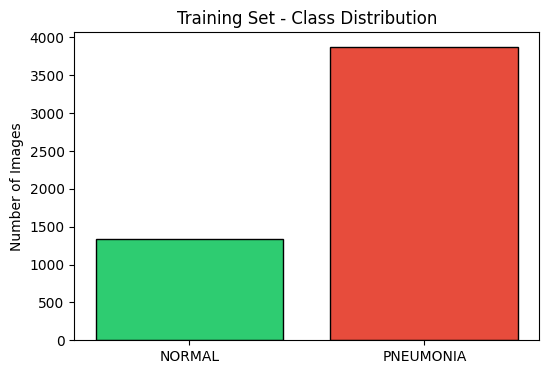

⚠️  Notice: Pneumonia images are 3x more than Normal — we'll handle this later!


In [10]:
# Our dataset has MORE pneumonia images than normal images
# This is called "class imbalance" — like if you had 100 red balls and 10 blue balls
# The AI might get lazy and just always guess "red"!
# We need to be aware of this and fix it later.

train_normal    = len(os.listdir(os.path.join(train_dir, "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))
total           = train_normal + train_pneumonia

print(f"Normal images    : {train_normal}  ({train_normal/total*100:.1f}%)")
print(f"Pneumonia images : {train_pneumonia}  ({train_pneumonia/total*100:.1f}%)")
print(f"Total            : {total}")

# Draw a bar chart
plt.figure(figsize=(6, 4))
plt.bar(["NORMAL", "PNEUMONIA"], [train_normal, train_pneumonia],
        color=["#2ecc71", "#e74c3c"], edgecolor="black")
plt.title("Training Set - Class Distribution")
plt.ylabel("Number of Images")
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("⚠️  Notice: Pneumonia images are 3x more than Normal — we'll handle this later!")

Image file      : IM-0115-0001.jpeg
Original size   : (2090, 1858)  (width x height in pixels)
As a grid of numbers, shape: (1858, 2090)
Pixel value range: 0 to 255

Top-left 5x5 corner of the image (just numbers!):
[[22 24 24 23 22]
 [23 24 24 22 22]
 [24 24 23 22 22]
 [24 24 23 23 23]
 [23 24 24 24 24]]


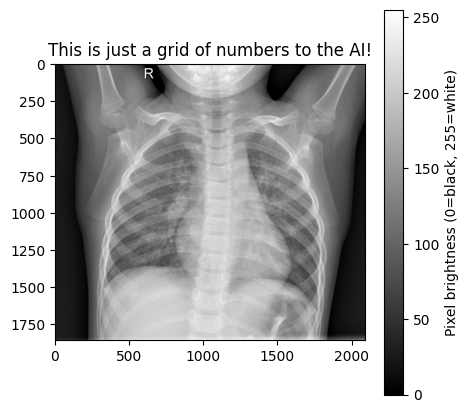

In [11]:
# Let's zoom into ONE image and understand what the computer actually "sees"
# Images are just grids of numbers (0=black, 255=white) to a computer!

sample_path = os.path.join(train_dir, "NORMAL", os.listdir(os.path.join(train_dir, "NORMAL"))[0])
img = Image.open(sample_path).convert("L")

print(f"Image file      : {os.path.basename(sample_path)}")
print(f"Original size   : {img.size}  (width x height in pixels)")

# Convert to numpy array so we can see the numbers
img_array = np.array(img)
print(f"As a grid of numbers, shape: {img_array.shape}")
print(f"Pixel value range: {img_array.min()} to {img_array.max()}")
print(f"\nTop-left 5x5 corner of the image (just numbers!):")
print(img_array[:5, :5])

# Show the image
plt.figure(figsize=(5,5))
plt.imshow(img_array, cmap="gray")
plt.title("This is just a grid of numbers to the AI!")
plt.colorbar(label="Pixel brightness (0=black, 255=white)")
plt.savefig("single_xray_detail.png", dpi=150)
plt.show()